# Problem Statement and Business Context

Concrete is one of the most widely used construction materials in civil engineering. The compressive strength of concrete is a critical property that determines its quality and durability. Predicting the compressive strength accurately can help in optimizing mix designs, reducing costs, and ensuring safety in construction projects.

This notebook develops a machine learning model to predict concrete compressive strength based on mixture ingredients and age.

# Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from kneed import KneeLocator
import joblib
import os
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# Load Dataset

In [5]:
# Load the dataset
data = pd.read_csv('inputFile.csv')

# Display basic information
print("Dataset Shape:", data.shape)
print("\nData Types:")
print(data.dtypes)
print("\nFirst 5 rows:")
data.head()

Dataset Shape: (1030, 9)

Data Types:
Cement                             float64
Blast Furnace Slag _component_2    float64
Fly Ash _component_3               float64
Water_component_4                  float64
Superplasticizer_component_5       float64
Coarse Aggregate_component_6       float64
Fine Aggregate_component_7         float64
Age_day                              int64
Concrete_compressive _strength     float64
dtype: object

First 5 rows:


,Cement,Blast Furnace Slag _component_2,Fly Ash _component_3,Water_component_4,Superplasticizer_component_5,Coarse Aggregate_component_6,Fine Aggregate_component_7,Age_day,Concrete_compressive _strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


# Exploratory Data Analysis (EDA)

In [7]:
# Summary statistics
data.describe()

,Cement,Blast Furnace Slag _component_2,Fly Ash _component_3,Water_component_4,Superplasticizer_component_5,Coarse Aggregate_component_6,Fine Aggregate_component_7,Age_day,Concrete_compressive _strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817971
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705746
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [8]:
# Check for missing values
print("Missing values per column:")
print(data.isnull().sum())
print(f"\nTotal missing values: {data.isnull().sum().sum()}")

Missing values per column:
Cement                             0
Blast Furnace Slag _component_2    0
Fly Ash _component_3               0
Water_component_4                  0
Superplasticizer_component_5       0
Coarse Aggregate_component_6       0
Fine Aggregate_component_7         0
Age_day                            0
Concrete_compressive _strength     0
dtype: int64

Total missing values: 0


In [9]:
# Check for duplicate rows
dup_count = data.duplicated().sum()
print(f"Number of duplicate rows: {dup_count}")
if dup_count > 0:
    print("Removing duplicates...")
    data = data.drop_duplicates().reset_index(drop=True)
    print(f"Shape after removing duplicates: {data.shape}")

Number of duplicate rows: 25
Removing duplicates...
Shape after removing duplicates: (1005, 9)


In [10]:
# Analyze zero values - some components are optional in concrete mixes
zero_counts = (data == 0).sum()
zero_pct = ((data == 0).sum() / len(data) * 100).round(1)
zero_df = pd.DataFrame({'Zero Count': zero_counts, 'Zero %': zero_pct})
print("Zero-value analysis (optional ingredients often have zeros):")
print(zero_df[zero_df['Zero Count'] > 0])

Zero-value analysis (optional ingredients often have zeros):
                                 Zero Count  Zero %
Blast Furnace Slag _component_2         470    46.8
Fly Ash _component_3                    541    53.8
Superplasticizer_component_5            378    37.6


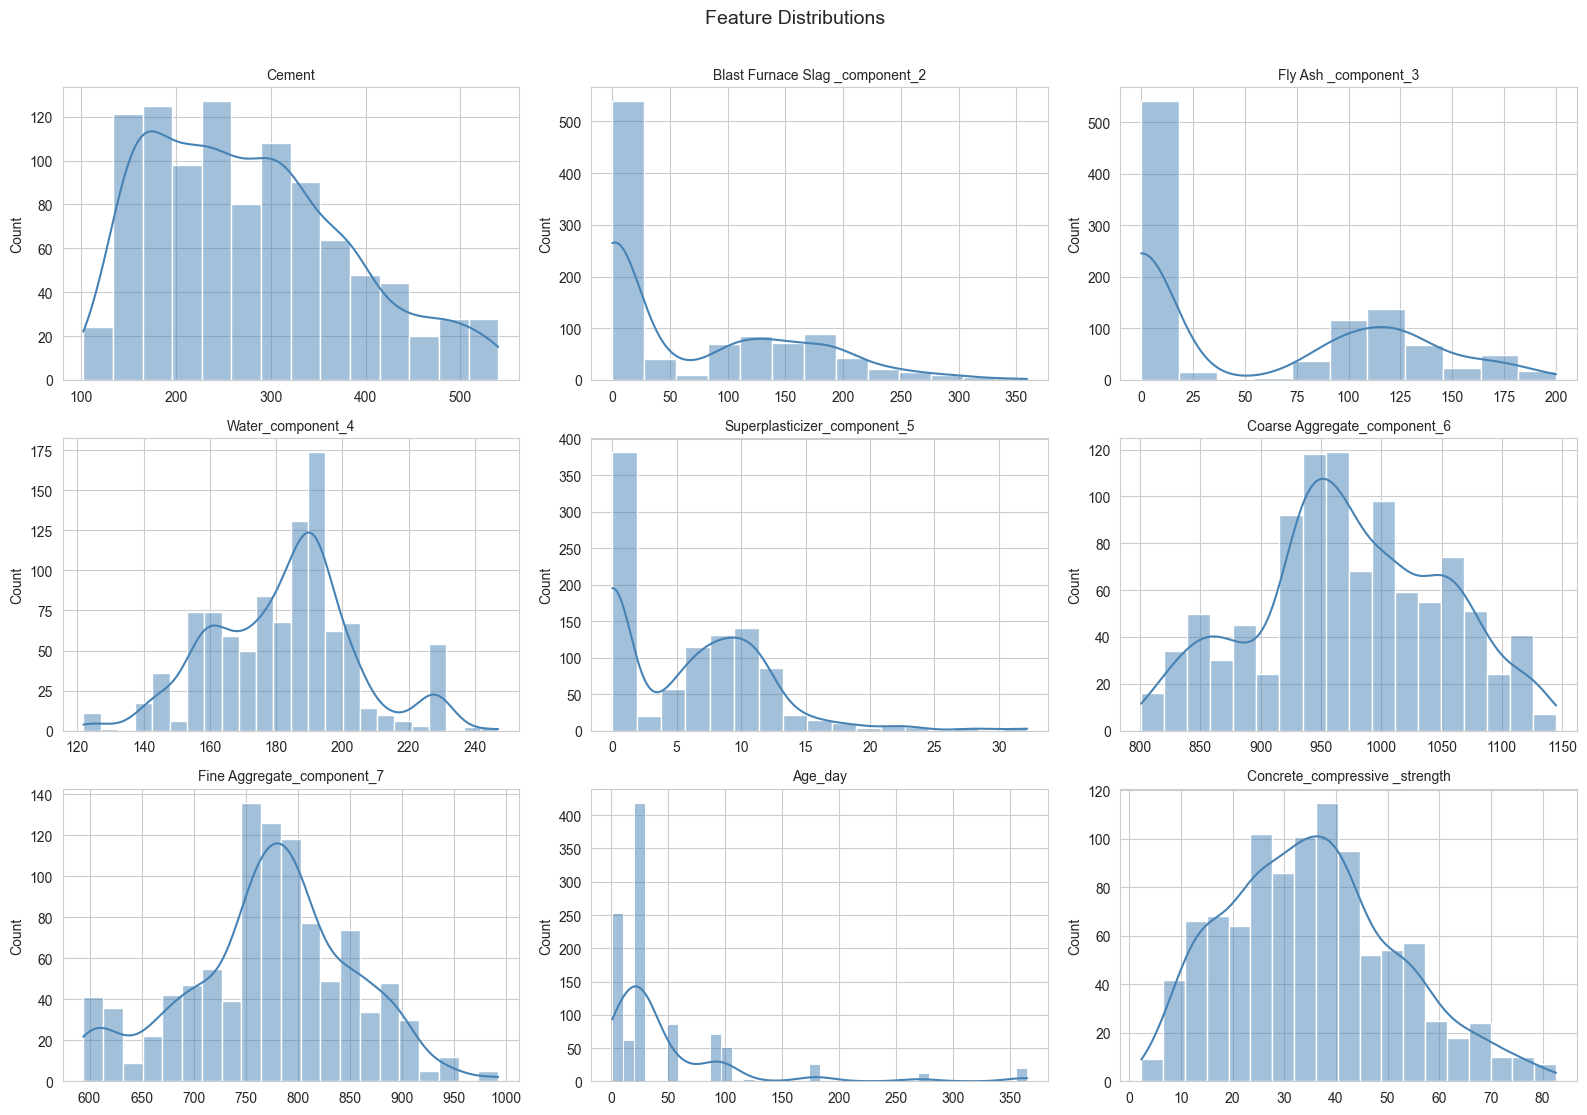

In [11]:
# Plot distributions of features
plt.figure(figsize=(16, 11))
for i, column in enumerate(data.columns):
    plt.subplot(3, 3, i+1)
    sns.histplot(data[column], kde=True, color='steelblue')
    plt.title(f'{column}', fontsize=10)
    plt.xlabel('')
plt.suptitle('Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

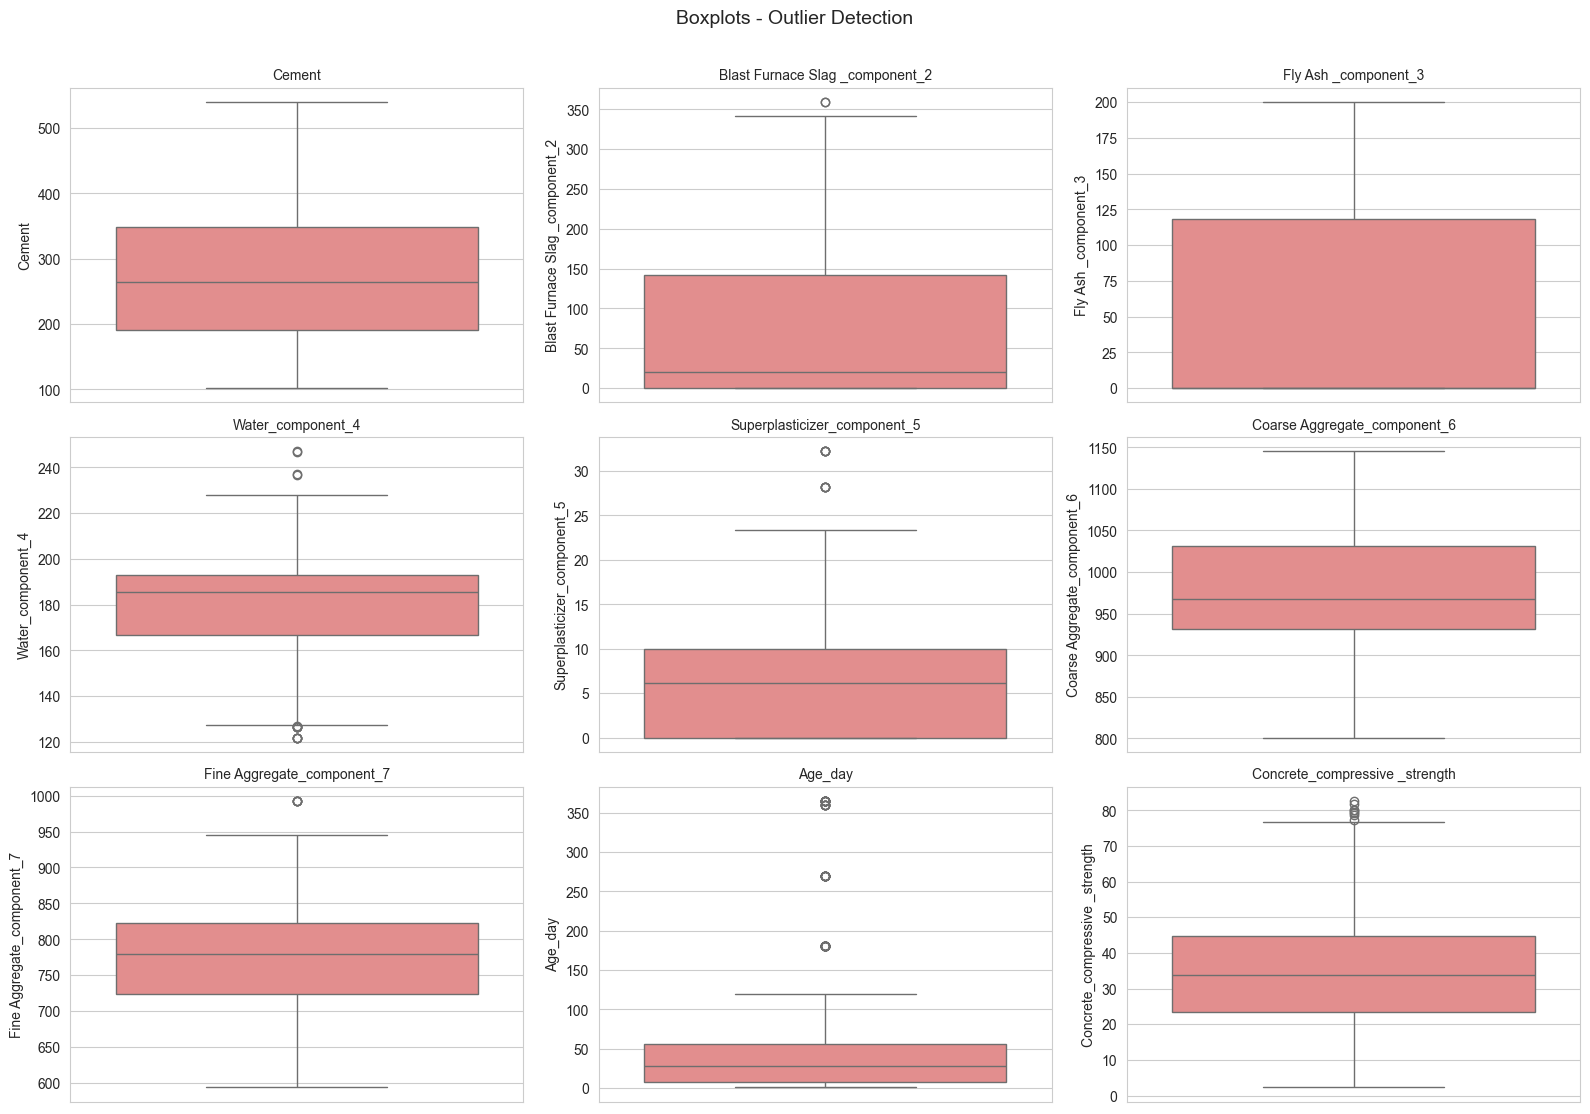

In [12]:
# Boxplots to detect outliers
plt.figure(figsize=(16, 11))
for i, column in enumerate(data.columns):
    plt.subplot(3, 3, i+1)
    sns.boxplot(y=data[column], color='lightcoral')
    plt.title(f'{column}', fontsize=10)
plt.suptitle('Boxplots - Outlier Detection', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [13]:
# Quantify outliers using the IQR method
print("Outlier counts per column (IQR method, 1.5x):")
for col in data.columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_outliers = ((data[col] < lower) | (data[col] > upper)).sum()
    if n_outliers > 0:
        print(f"  {col}: {n_outliers} outliers")

Outlier counts per column (IQR method, 1.5x):
  Blast Furnace Slag _component_2: 2 outliers
  Water_component_4: 15 outliers
  Superplasticizer_component_5: 10 outliers
  Fine Aggregate_component_7: 5 outliers
  Age_day: 59 outliers
  Concrete_compressive _strength: 8 outliers


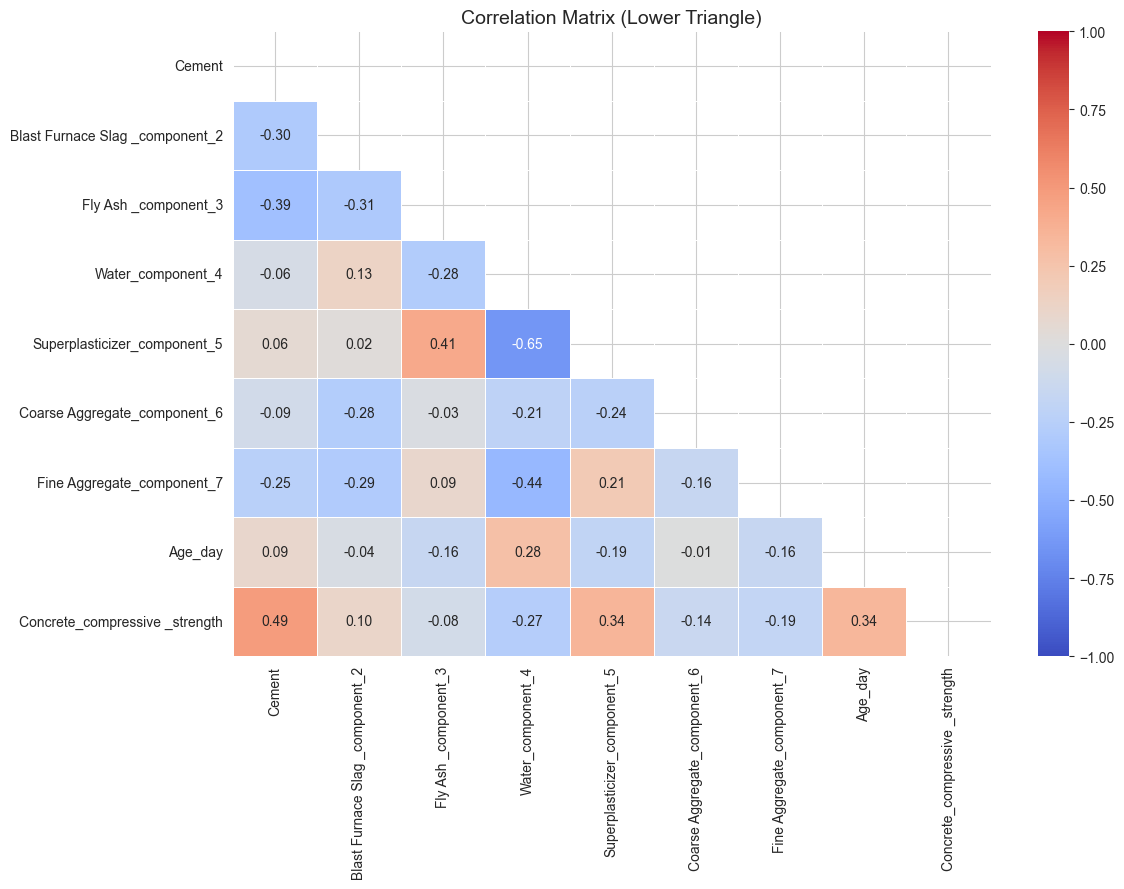

In [14]:
# Correlation heatmap
plt.figure(figsize=(12, 9))
corr = data.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', mask=mask,
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix (Lower Triangle)', fontsize=14)
plt.tight_layout()
plt.show()

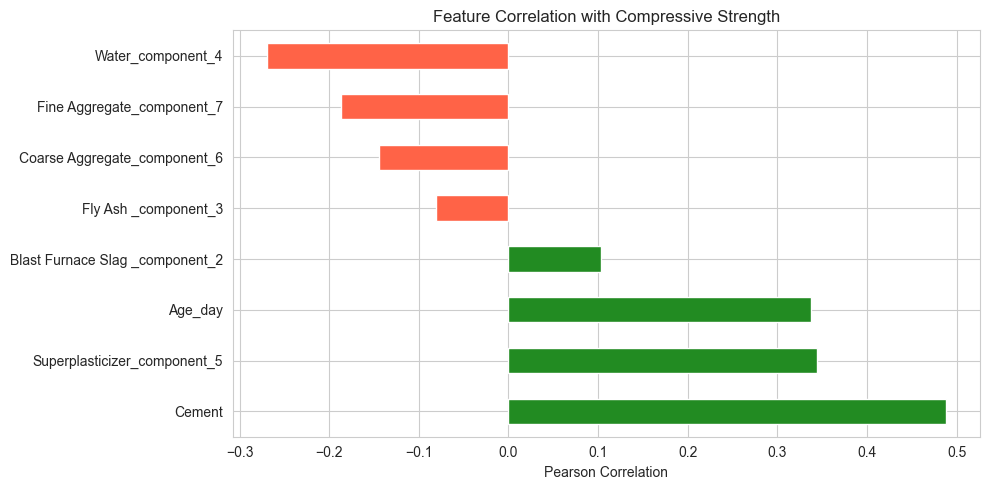


Correlation with target:
Cement                             0.488
Superplasticizer_component_5       0.344
Age_day                            0.337
Blast Furnace Slag _component_2    0.103
Fly Ash _component_3              -0.081
Coarse Aggregate_component_6      -0.145
Fine Aggregate_component_7        -0.186
Water_component_4                 -0.270
Name: Concrete_compressive _strength, dtype: float64


In [15]:
# Correlation with target variable - sorted
target_col = 'Concrete_compressive _strength'
target_corr = data.corr()[target_col].drop(target_col).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
colors = ['forestgreen' if v > 0 else 'tomato' for v in target_corr.values]
target_corr.plot(kind='barh', color=colors)
plt.title('Feature Correlation with Compressive Strength')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

print("\nCorrelation with target:")
print(target_corr.round(3))

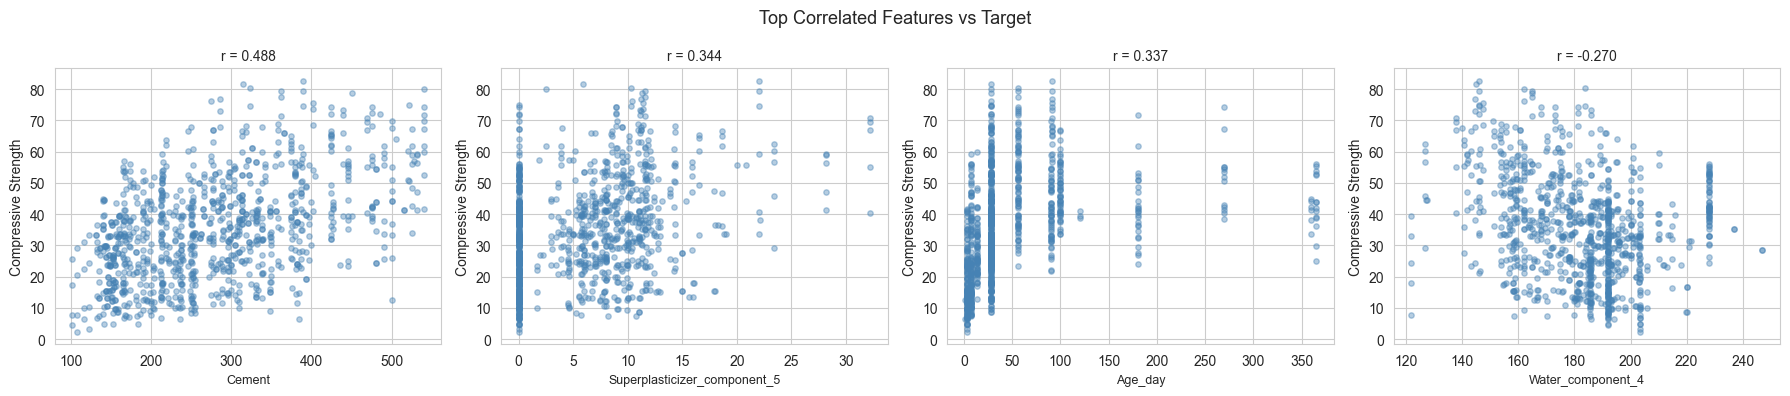

In [16]:
# Scatter plots of top correlated features vs target
top_features = target_corr.abs().sort_values(ascending=False).head(4).index.tolist()

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, feat in zip(axes, top_features):
    ax.scatter(data[feat], data[target_col], alpha=0.4, s=15, color='steelblue')
    ax.set_xlabel(feat, fontsize=9)
    ax.set_ylabel('Compressive Strength')
    ax.set_title(f'r = {data[feat].corr(data[target_col]):.3f}', fontsize=10)
plt.suptitle('Top Correlated Features vs Target', fontsize=13)
plt.tight_layout()
plt.show()

# Feature Engineering

In [18]:
# Create domain-informed features
data_fe = data.copy()

# Water-to-cement ratio - a key indicator in civil engineering
data_fe['Water_Cement_Ratio'] = data_fe['Water_component_4'] / data_fe['Cement']

# Total binder (cement + slag + fly ash)
data_fe['Total_Binder'] = (
    data_fe['Cement'] +
    data_fe['Blast Furnace Slag _component_2'] +
    data_fe['Fly Ash _component_3']
)

# Water-to-binder ratio
data_fe['Water_Binder_Ratio'] = data_fe['Water_component_4'] / data_fe['Total_Binder']

# Total aggregate
data_fe['Total_Aggregate'] = (
    data_fe['Coarse Aggregate_component_6'] +
    data_fe['Fine Aggregate_component_7']
)

# Coarse-to-fine aggregate ratio
data_fe['Coarse_Fine_Ratio'] = (
    data_fe['Coarse Aggregate_component_6'] /
    data_fe['Fine Aggregate_component_7']
)

# Log of Age (strength gain is roughly logarithmic with age)
data_fe['Log_Age'] = np.log1p(data_fe['Age_day'])

print("New features added:")
new_cols = ['Water_Cement_Ratio', 'Total_Binder', 'Water_Binder_Ratio',
            'Total_Aggregate', 'Coarse_Fine_Ratio', 'Log_Age']
print(data_fe[new_cols].describe().round(3))

New features added:
       Water_Cement_Ratio  Total_Binder  Water_Binder_Ratio  Total_Aggregate  \
count            1005.000      1005.000            1005.000         1005.000   
mean                0.756       406.211               0.473         1747.065   
std                 0.314        91.421               0.125          102.232   
min                 0.267       200.000               0.235         1457.000   
25%                 0.547       336.300               0.390         1679.000   
50%                 0.690       388.400               0.480         1758.300   
75%                 0.937       480.000               0.561         1829.000   
max                 1.882       640.000               0.900         1970.000   

       Coarse_Fine_Ratio   Log_Age  
count           1005.000  1005.000  
mean               1.277     3.245  
std                0.185     1.109  
min                0.858     0.693  
25%                1.121     2.079  
50%                1.284     3.367  


In [19]:
# Check correlation of new features with target
new_corr = data_fe[new_cols + [target_col]].corr()[target_col].drop(target_col).sort_values(ascending=False)
print("New feature correlations with compressive strength:")
print(new_corr.round(3))

New feature correlations with compressive strength:
Total_Binder          0.598
Log_Age               0.560
Coarse_Fine_Ratio     0.075
Total_Aggregate      -0.256
Water_Cement_Ratio   -0.489
Water_Binder_Ratio   -0.611
Name: Concrete_compressive _strength, dtype: float64


# Data Preprocessing

In [21]:
# Separate features and target (using engineered features)
X = data_fe.drop(target_col, axis=1)
y = data_fe[target_col]

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:")
print(list(X.columns))

Features shape: (1005, 14)
Target shape: (1005,)

Feature columns:
['Cement', 'Blast Furnace Slag _component_2', 'Fly Ash _component_3', 'Water_component_4', 'Superplasticizer_component_5', 'Coarse Aggregate_component_6', 'Fine Aggregate_component_7', 'Age_day', 'Water_Cement_Ratio', 'Total_Binder', 'Water_Binder_Ratio', 'Total_Aggregate', 'Coarse_Fine_Ratio', 'Log_Age']


In [22]:
# Apply log transformation to features (log1p handles zeros safely)
X_log = X.copy()
for column in X_log.columns:
    X_log[column] = np.log1p(X_log[column])

print("Log transformed features:")
X_log.head()

Log transformed features:


,Cement,Blast Furnace Slag _component_2,Fly Ash _component_3,Water_component_4,Superplasticizer_component_5,Coarse Aggregate_component_6,Fine Aggregate_component_7,Age_day,Water_Cement_Ratio,Total_Binder,Water_Binder_Ratio,Total_Aggregate,Coarse_Fine_Ratio,Log_Age
0,6.293419,0.000000,0.0,5.093750,1.252763,6.947937,6.517671,3.367296,0.262364,6.293419,0.262364,7.448334,0.931558,1.474144
1,6.293419,0.000000,0.0,5.093750,1.252763,6.962243,6.517671,3.367296,0.262364,6.293419,0.262364,7.457032,0.940261,1.474144
2,5.809643,4.966335,0.0,5.433722,0.000000,6.838405,6.388561,5.602119,0.522189,6.165418,0.392042,7.331060,0.943526,1.887391
3,5.809643,4.966335,0.0,5.433722,0.000000,6.838405,6.388561,5.902633,0.522189,6.165418,0.392042,7.331060,0.943526,1.931903
4,5.296315,4.893352,0.0,5.262690,0.000000,6.886940,6.717200,5.888878,0.676391,5.805135,0.457463,7.498260,0.781717,1.929908


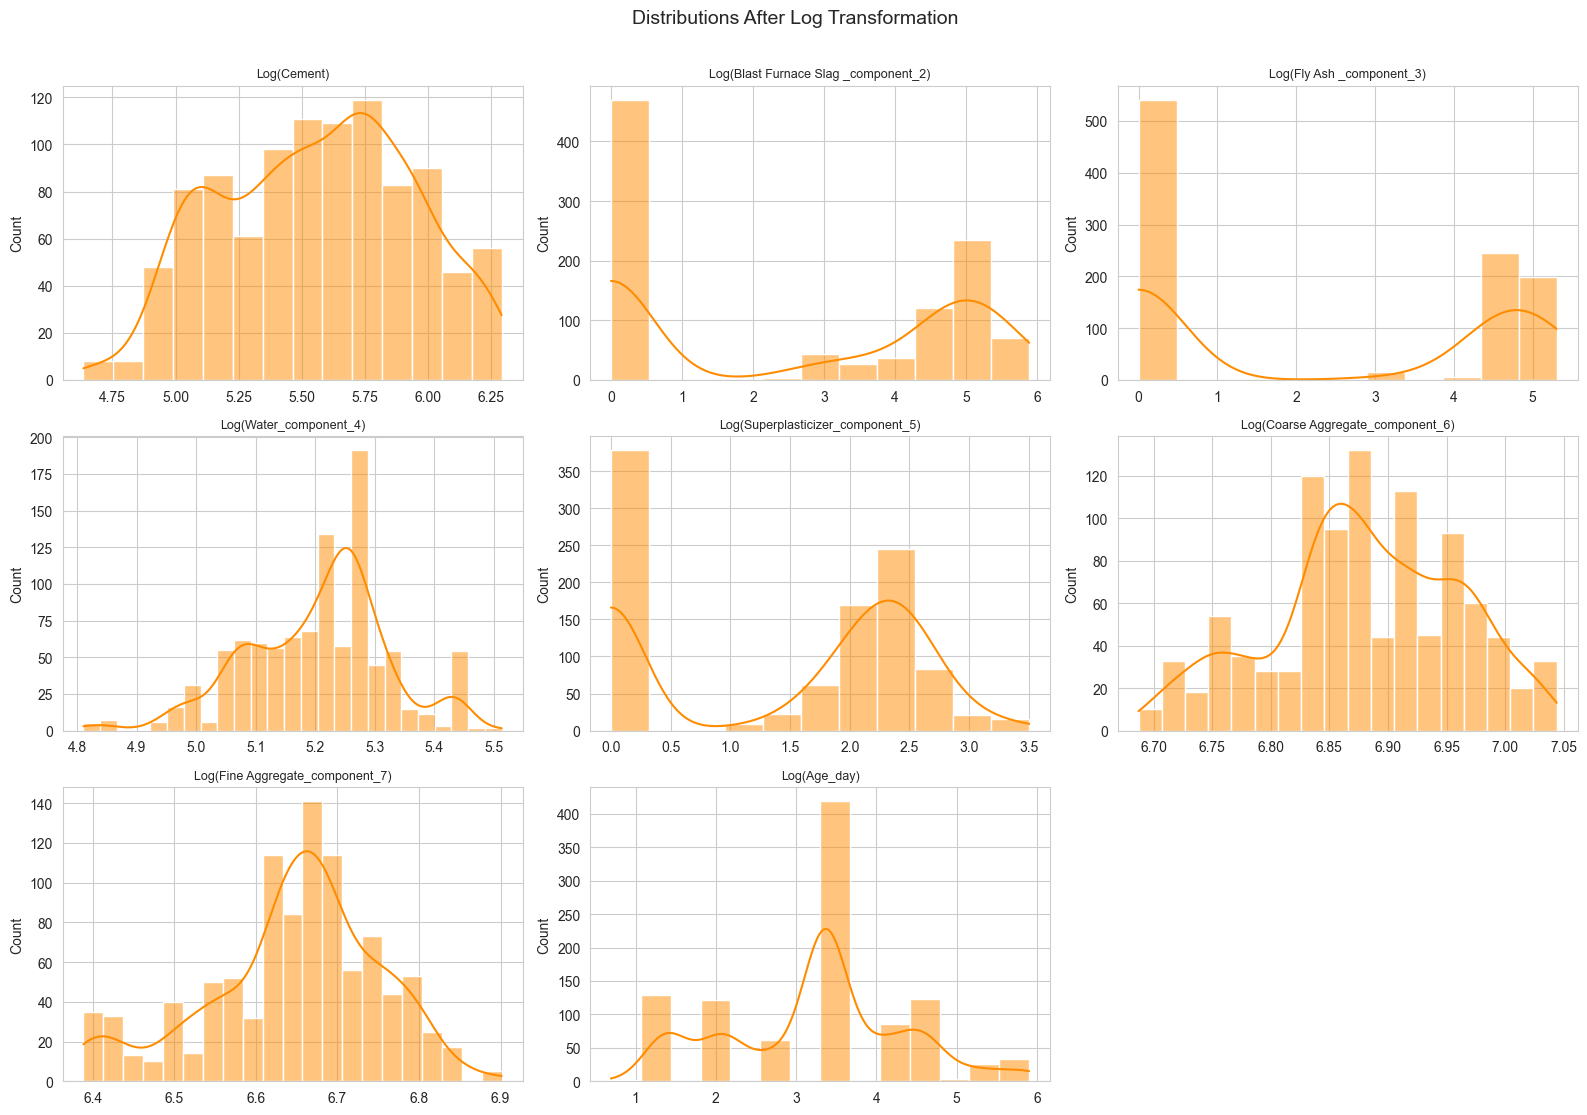

In [23]:
# Plot distributions after log transformation (original 8 features)
original_features = data.drop(target_col, axis=1).columns.tolist()
plt.figure(figsize=(16, 11))
for i, column in enumerate(original_features):
    plt.subplot(3, 3, i+1)
    sns.histplot(X_log[column], kde=True, color='darkorange')
    plt.title(f'Log({column})', fontsize=9)
    plt.xlabel('')
plt.suptitle('Distributions After Log Transformation', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Clustering

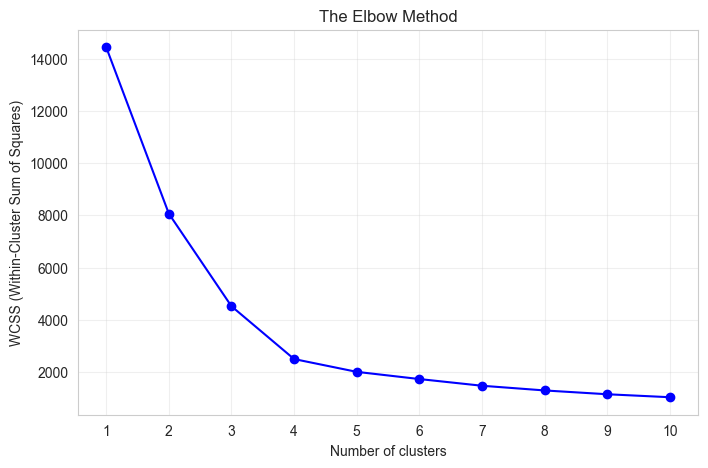

Optimal number of clusters: 4


In [25]:
# Elbow plot to determine optimal number of clusters
wcss = []
K_range = range(1, 11)
for i in K_range:
    km = KMeans(n_clusters=i, init='k-means++', n_init=10, random_state=42)
    km.fit(X_log)
    wcss.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, 'bo-')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.show()

# Find optimal clusters using KneeLocator
kn = KneeLocator(list(K_range), wcss, curve='convex', direction='decreasing')
optimal_clusters = kn.knee
print(f'Optimal number of clusters: {optimal_clusters}')

In [26]:
# Create clusters
kmeans = KMeans(n_clusters=optimal_clusters, init='k-means++', n_init=10, random_state=42)
X_clustered = X_log.copy()
X_clustered['Cluster'] = kmeans.fit_predict(X_log)
X_clustered['Labels'] = y.values

print("Clustered data shape:", X_clustered.shape)
print("\nCluster distribution:")
print(X_clustered['Cluster'].value_counts().sort_index())
print("\nMean compressive strength per cluster:")
print(X_clustered.groupby('Cluster')['Labels'].mean().round(2))

Clustered data shape: (1005, 16)

Cluster distribution:
Cluster
0    225
1    231
2    310
3    239
Name: count, dtype: int64

Mean compressive strength per cluster:
Cluster
0    38.30
1    32.04
2    38.53
3    31.22
Name: Labels, dtype: float64


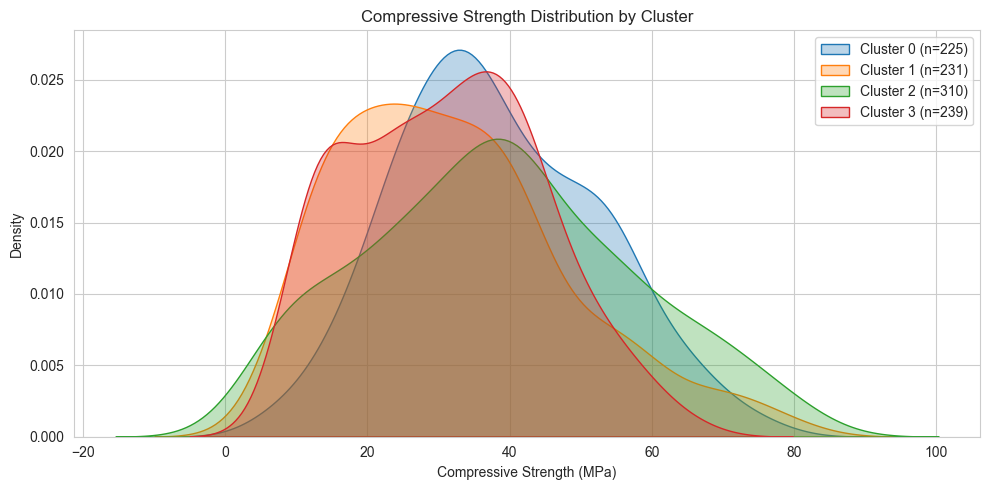

In [27]:
# Visualize clusters - strength distribution per cluster
plt.figure(figsize=(10, 5))
for c in sorted(X_clustered['Cluster'].unique()):
    subset = X_clustered[X_clustered['Cluster'] == c]['Labels']
    sns.kdeplot(subset, label=f'Cluster {c} (n={len(subset)})', fill=True, alpha=0.3)
plt.xlabel('Compressive Strength (MPa)')
plt.title('Compressive Strength Distribution by Cluster')
plt.legend()
plt.tight_layout()
plt.show()

# Model Training and Evaluation

We train multiple models per cluster and pick the best one based on R2 score:
- Linear Regression
- Ridge Regression
- Lasso Regression
- Random Forest Regressor
- Gradient Boosting Regressor
- SVR

In [29]:
def tune_linear_regression(X_train, y_train):
    param_grid = {'fit_intercept': [True, False]}
    grid = GridSearchCV(LinearRegression(), param_grid, cv=5, scoring='r2')
    grid.fit(X_train, y_train)
    return grid.best_estimator_, grid.best_score_

def tune_ridge(X_train, y_train):
    param_grid = {'alpha': [0.01, 0.1, 1, 10, 100]}
    grid = GridSearchCV(Ridge(), param_grid, cv=5, scoring='r2')
    grid.fit(X_train, y_train)
    return grid.best_estimator_, grid.best_score_

def tune_lasso(X_train, y_train):
    param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10]}
    grid = GridSearchCV(Lasso(max_iter=10000), param_grid, cv=5, scoring='r2')
    grid.fit(X_train, y_train)
    return grid.best_estimator_, grid.best_score_

def tune_random_forest(X_train, y_train):
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5],
        'bootstrap': [True, False]
    }
    grid = GridSearchCV(RandomForestRegressor(random_state=42), param_grid,
                        cv=5, scoring='r2', n_jobs=-1)
    grid.fit(X_train, y_train)
    return grid.best_estimator_, grid.best_score_

def tune_gradient_boosting(X_train, y_train):
    param_grid = {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5],
        'min_samples_split': [2, 5]
    }
    grid = GridSearchCV(GradientBoostingRegressor(random_state=42), param_grid,
                        cv=5, scoring='r2')
    grid.fit(X_train, y_train)
    return grid.best_estimator_, grid.best_score_

def tune_svr(X_train, y_train):
    param_grid = {
        'C': [1, 10, 100],
        'kernel': ['rbf'],
        'gamma': ['scale', 'auto']
    }
    grid = GridSearchCV(SVR(), param_grid, cv=5, scoring='r2')
    grid.fit(X_train, y_train)
    return grid.best_estimator_, grid.best_score_

In [30]:
# Train and evaluate models per cluster
best_models = {}
all_results = []

model_tuners = {
    'LinearRegression': tune_linear_regression,
    'Ridge': tune_ridge,
    'Lasso': tune_lasso,
    'RandomForest': tune_random_forest,
    'GradientBoosting': tune_gradient_boosting,
    'SVR': tune_svr
}

for cluster in sorted(X_clustered['Cluster'].unique()):
    print(f"\n{'='*60}")
    print(f"Processing Cluster {cluster}")
    print(f"{'='*60}")
    
    cluster_data = X_clustered[X_clustered['Cluster'] == cluster]
    cluster_features = cluster_data.drop(['Labels', 'Cluster'], axis=1)
    cluster_label = cluster_data['Labels']
    print(f"Samples in cluster: {len(cluster_data)}")
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        cluster_features, cluster_label, test_size=0.2, random_state=42
    )
    
    # Scale data
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    best_r2 = -np.inf
    best_name = None
    best_model = None
    
    for name, tuner in model_tuners.items():
        model, cv_score = tuner(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae = mean_absolute_error(y_test, y_pred)
        
        print(f"  {name:25s} | R2={r2:.4f} | RMSE={rmse:.2f} | MAE={mae:.2f} | CV_R2={cv_score:.4f}")
        all_results.append({
            'Cluster': cluster, 'Model': name,
            'R2': round(r2, 4), 'RMSE': round(rmse, 2),
            'MAE': round(mae, 2), 'CV_R2': round(cv_score, 4)
        })
        
        if r2 > best_r2:
            best_r2 = r2
            best_name = name
            best_model = model
    
    best_models[cluster] = (best_name, best_model, scaler)
    print(f"\n  >>> Best model for Cluster {cluster}: {best_name} (R2={best_r2:.4f})")


Processing Cluster 0
Samples in cluster: 225
  LinearRegression          | R2=0.7664 | RMSE=7.26 | MAE=5.87 | CV_R2=0.7620
  Ridge                     | R2=0.7671 | RMSE=7.25 | MAE=5.83 | CV_R2=0.7576
  Lasso                     | R2=0.7686 | RMSE=7.22 | MAE=5.77 | CV_R2=0.7563
  RandomForest              | R2=0.8599 | RMSE=5.62 | MAE=4.29 | CV_R2=0.7967
  GradientBoosting          | R2=0.9142 | RMSE=4.40 | MAE=3.03 | CV_R2=0.8575
  SVR                       | R2=0.8949 | RMSE=4.87 | MAE=3.13 | CV_R2=0.8013

  >>> Best model for Cluster 0: GradientBoosting (R2=0.9142)

Processing Cluster 1
Samples in cluster: 231
  LinearRegression          | R2=0.8581 | RMSE=5.84 | MAE=4.31 | CV_R2=0.8565
  Ridge                     | R2=0.8557 | RMSE=5.89 | MAE=4.43 | CV_R2=0.8572
  Lasso                     | R2=0.8560 | RMSE=5.88 | MAE=4.43 | CV_R2=0.8572
  RandomForest              | R2=0.8996 | RMSE=4.91 | MAE=3.39 | CV_R2=0.9135
  GradientBoosting          | R2=0.9427 | RMSE=3.71 | MAE=2.70 | C

In [31]:
# Results summary table
results_df = pd.DataFrame(all_results)
print("\nFull Results Table:")
results_df.sort_values(['Cluster', 'R2'], ascending=[True, False])


Full Results Table:


,Cluster,Model,R2,RMSE,MAE,CV_R2
4,0,GradientBoosting,0.9142,4.40,3.03,0.8575
5,0,SVR,0.8949,4.87,3.13,0.8013
3,0,RandomForest,0.8599,5.62,4.29,0.7967
2,0,Lasso,0.7686,7.22,5.77,0.7563
1,0,Ridge,0.7671,7.25,5.83,0.7576
0,0,LinearRegression,0.7664,7.26,5.87,0.7620
10,1,GradientBoosting,0.9427,3.71,2.70,0.9272
11,1,SVR,0.9247,4.26,2.69,0.8827
9,1,RandomForest,0.8996,4.91,3.39,0.9135
6,1,LinearRegression,0.8581,5.84,4.31,0.8565


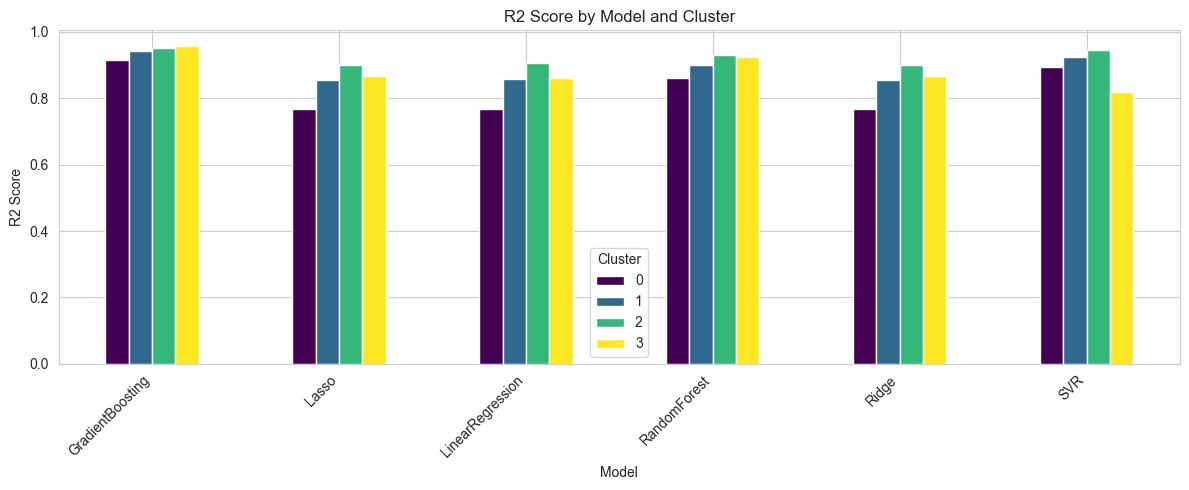

In [32]:
# Visualize R2 scores across models and clusters
pivot = results_df.pivot(index='Model', columns='Cluster', values='R2')
pivot.plot(kind='bar', figsize=(12, 5), colormap='viridis')
plt.title('R2 Score by Model and Cluster')
plt.ylabel('R2 Score')
plt.xlabel('Model')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

# Residual Analysis

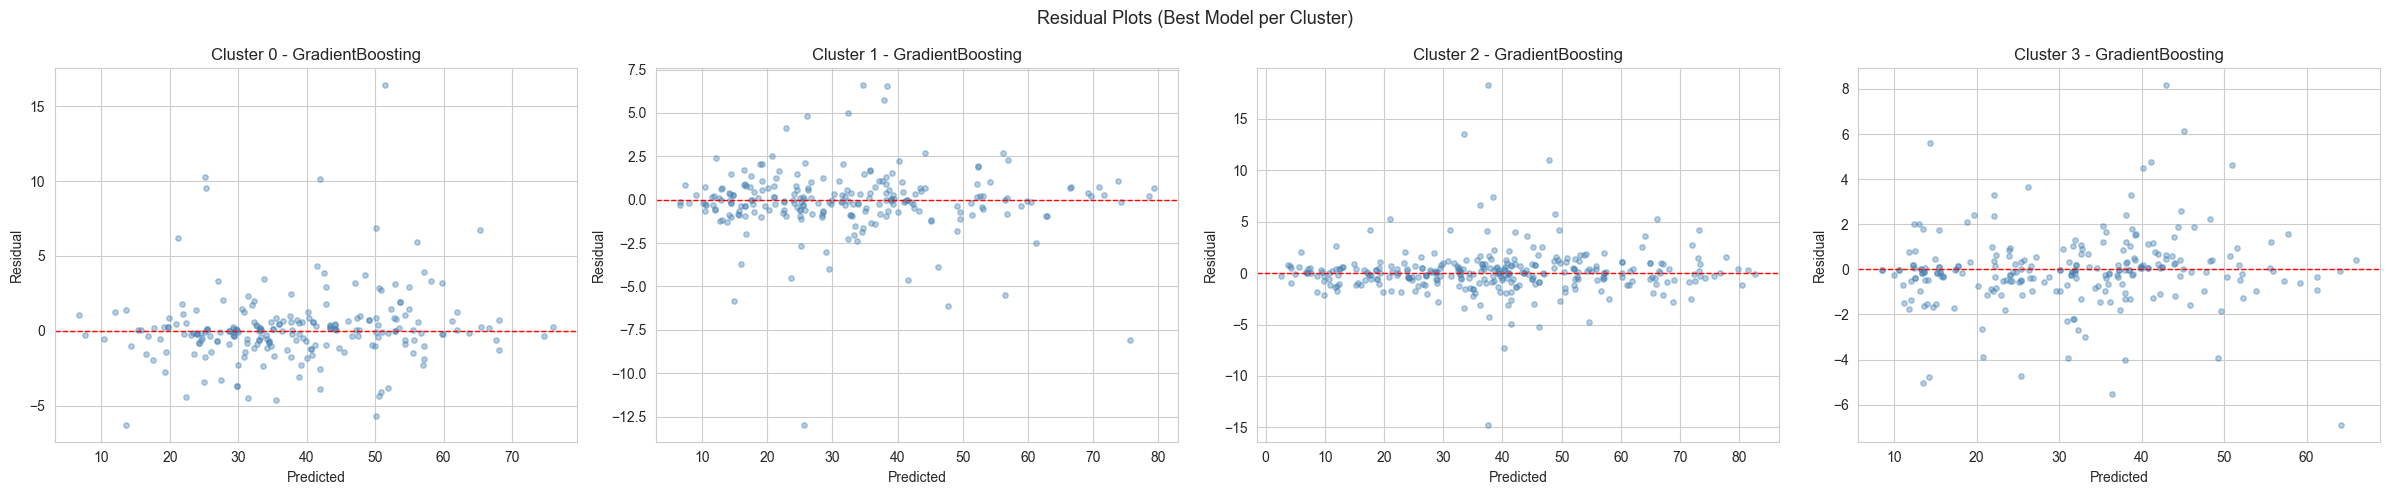

In [34]:
# Residual plots for the best model in each cluster
n_clusters = len(best_models)
fig, axes = plt.subplots(1, n_clusters, figsize=(6 * n_clusters, 5))
if n_clusters == 1:
    axes = [axes]

for idx, (cluster, (model_name, model, scaler)) in enumerate(sorted(best_models.items())):
    cluster_data = X_clustered[X_clustered['Cluster'] == cluster]
    cluster_features = cluster_data.drop(['Labels', 'Cluster'], axis=1)
    cluster_label = cluster_data['Labels']
    
    X_scaled = scaler.transform(cluster_features)
    y_pred = model.predict(X_scaled)
    residuals = cluster_label.values - y_pred
    
    ax = axes[idx]
    ax.scatter(y_pred, residuals, alpha=0.4, s=15, color='steelblue')
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Residual')
    ax.set_title(f'Cluster {cluster} - {model_name}')

plt.suptitle('Residual Plots (Best Model per Cluster)', fontsize=13)
plt.tight_layout()
plt.show()

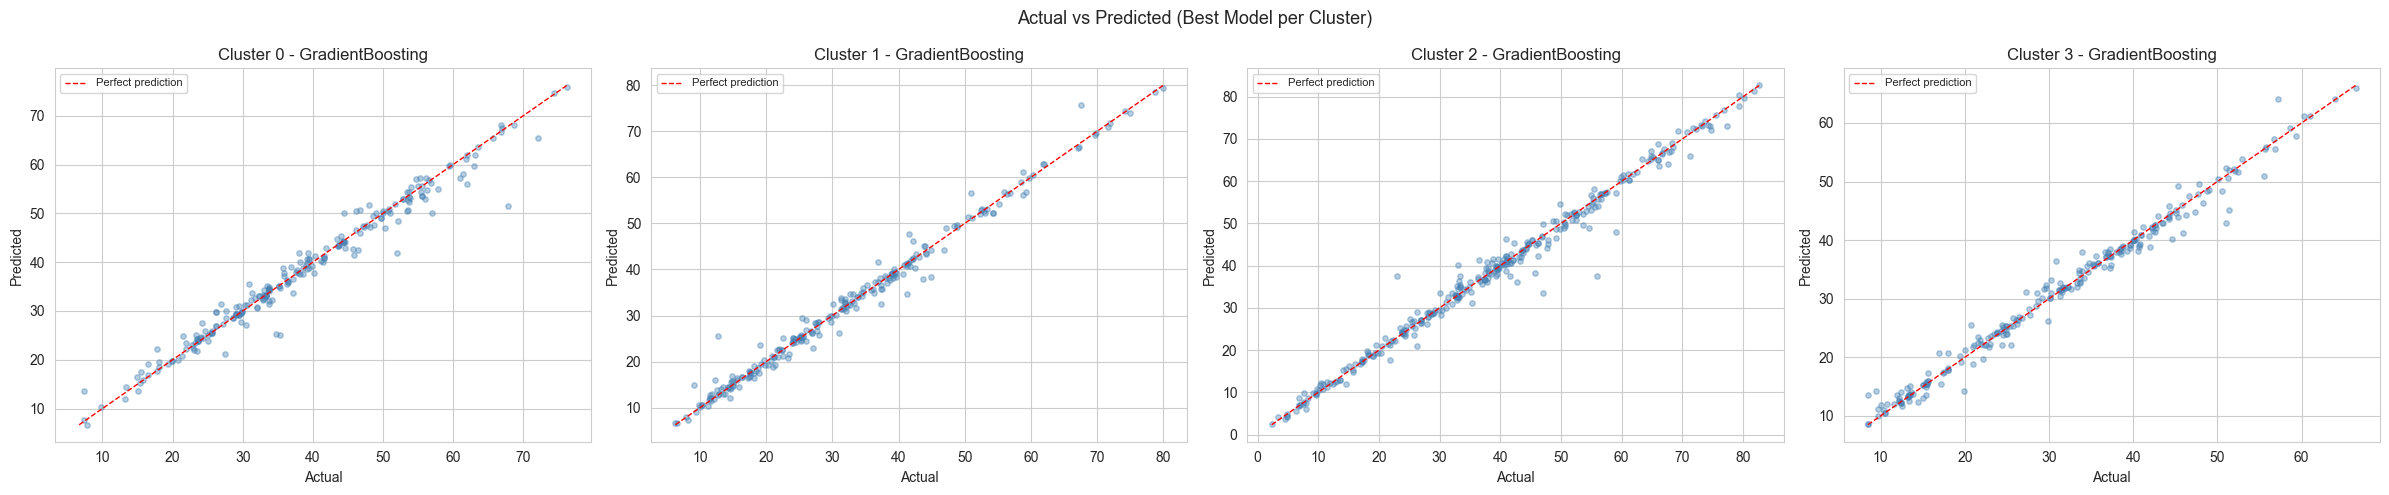

In [35]:
# Actual vs Predicted plots
fig, axes = plt.subplots(1, n_clusters, figsize=(6 * n_clusters, 5))
if n_clusters == 1:
    axes = [axes]

for idx, (cluster, (model_name, model, scaler)) in enumerate(sorted(best_models.items())):
    cluster_data = X_clustered[X_clustered['Cluster'] == cluster]
    cluster_features = cluster_data.drop(['Labels', 'Cluster'], axis=1)
    cluster_label = cluster_data['Labels']
    
    X_scaled = scaler.transform(cluster_features)
    y_pred = model.predict(X_scaled)
    
    ax = axes[idx]
    ax.scatter(cluster_label, y_pred, alpha=0.4, s=15, color='steelblue')
    lims = [min(cluster_label.min(), y_pred.min()), max(cluster_label.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(f'Cluster {cluster} - {model_name}')
    ax.legend(fontsize=8)

plt.suptitle('Actual vs Predicted (Best Model per Cluster)', fontsize=13)
plt.tight_layout()
plt.show()

# Feature Importance Analysis

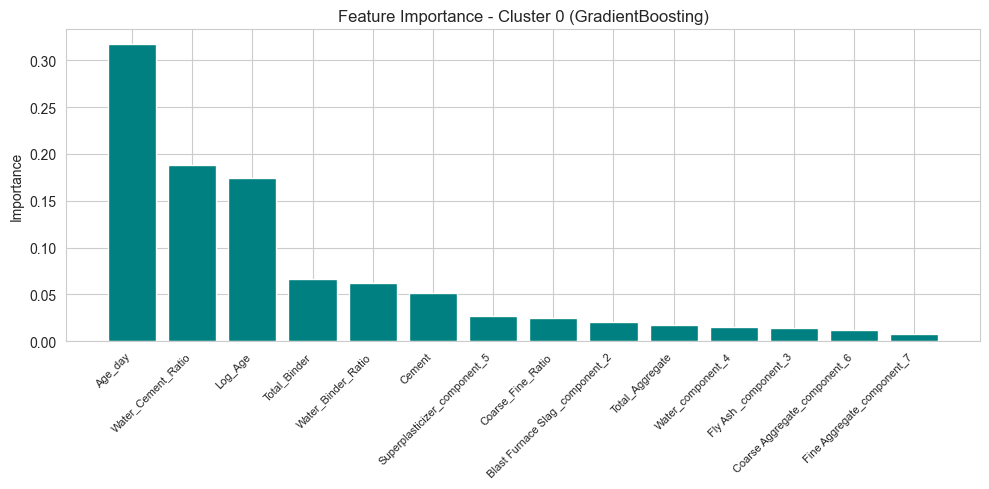

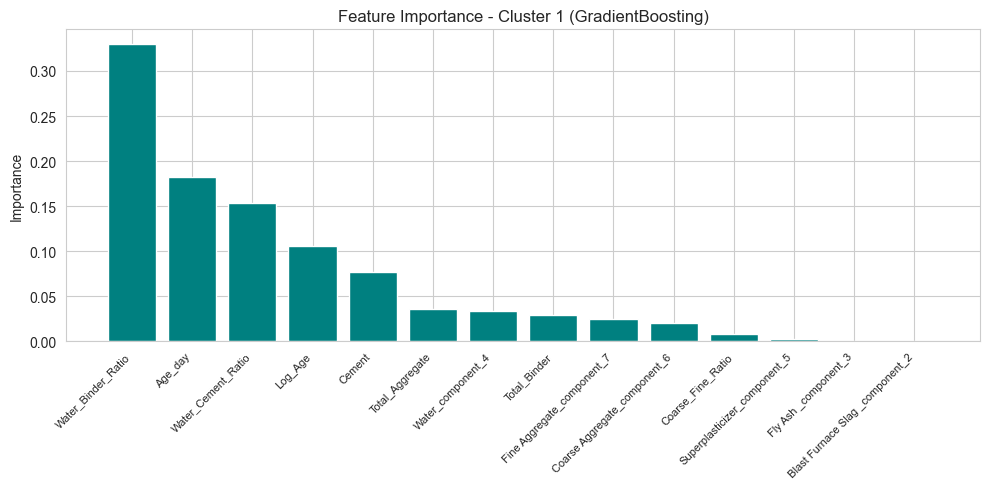

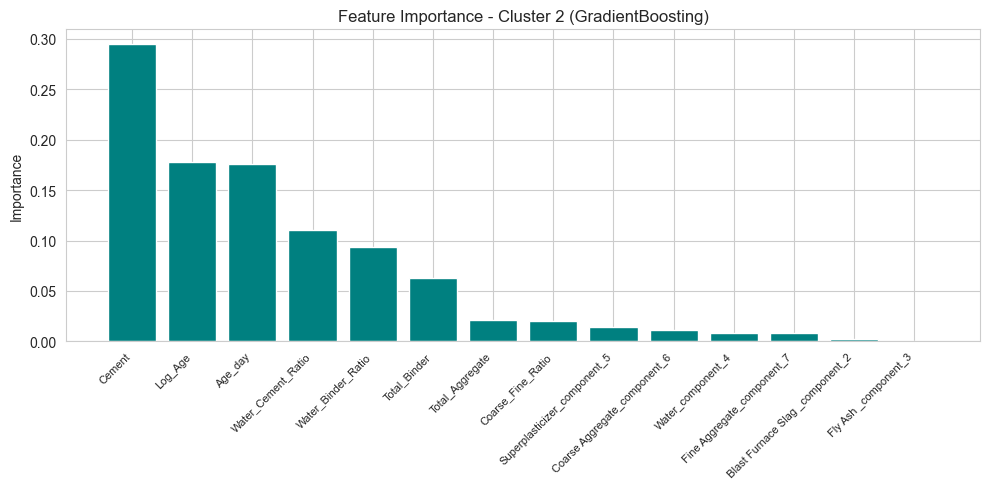

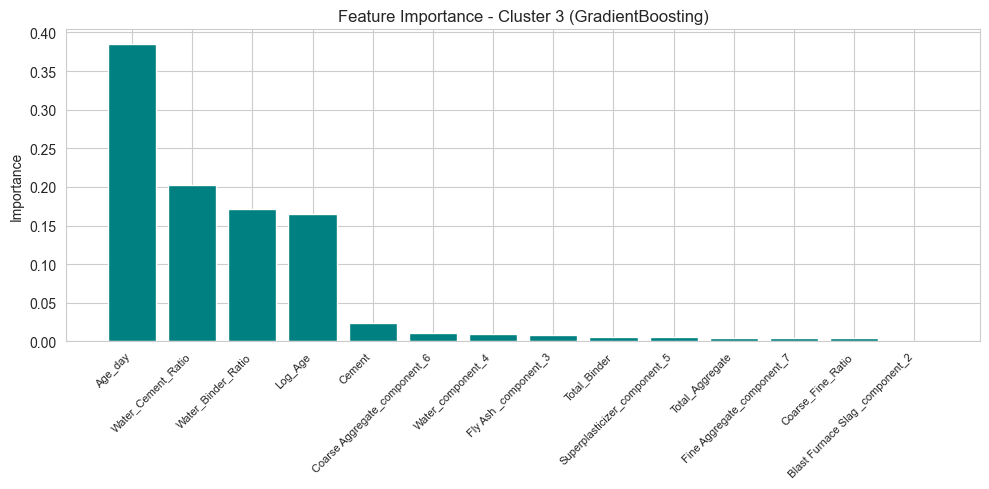

In [37]:
# Feature importance for best models in each cluster
feature_names = X_clustered.drop(['Labels', 'Cluster'], axis=1).columns.tolist()

for cluster, (model_name, model, scaler) in sorted(best_models.items()):
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        sorted_idx = np.argsort(importances)[::-1]
        
        plt.figure(figsize=(10, 5))
        plt.bar(range(len(importances)), importances[sorted_idx], color='teal')
        plt.xticks(range(len(importances)),
                   [feature_names[i] for i in sorted_idx],
                   rotation=45, ha='right', fontsize=8)
        plt.title(f'Feature Importance - Cluster {cluster} ({model_name})')
        plt.ylabel('Importance')
        plt.tight_layout()
        plt.show()
    elif hasattr(model, 'coef_'):
        coefs = np.abs(model.coef_)
        sorted_idx = np.argsort(coefs)[::-1]
        
        plt.figure(figsize=(10, 5))
        plt.bar(range(len(coefs)), coefs[sorted_idx], color='coral')
        plt.xticks(range(len(coefs)),
                   [feature_names[i] for i in sorted_idx],
                   rotation=45, ha='right', fontsize=8)
        plt.title(f'|Coefficients| - Cluster {cluster} ({model_name})')
        plt.ylabel('|Coefficient|')
        plt.tight_layout()
        plt.show()
    else:
        print(f"Cluster {cluster} ({model_name}): No native feature importance available.")

# Global Baseline Comparison (Without Clustering)

In [39]:
# Train a single global model as a baseline to show the value of clustering
X_global = X_log.copy()
y_global = y.copy()

X_tr, X_te, y_tr, y_te = train_test_split(X_global, y_global, test_size=0.2, random_state=42)

scaler_global = StandardScaler()
X_tr_s = scaler_global.fit_transform(X_tr)
X_te_s = scaler_global.transform(X_te)

global_models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1),
    'RandomForest': RandomForestRegressor(n_estimators=200, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=200, random_state=42),
    'SVR': SVR(C=100, kernel='rbf')
}

print("Global Baseline (no clustering):")
print(f"{'Model':25s} | {'R2':>8s} | {'RMSE':>8s} | {'MAE':>8s}")
print('-' * 58)
for name, mdl in global_models.items():
    mdl.fit(X_tr_s, y_tr)
    yp = mdl.predict(X_te_s)
    r2 = r2_score(y_te, yp)
    rmse = np.sqrt(mean_squared_error(y_te, yp))
    mae = mean_absolute_error(y_te, yp)
    print(f"{name:25s} | {r2:8.4f} | {rmse:8.2f} | {mae:8.2f}")

Global Baseline (no clustering):
Model                     |       R2 |     RMSE |      MAE
----------------------------------------------------------
LinearRegression          |   0.8243 |     7.24 |     5.58
Ridge                     |   0.8249 |     7.23 |     5.55
RandomForest              |   0.9191 |     4.91 |     3.50
GradientBoosting          |   0.9340 |     4.44 |     3.13
SVR                       |   0.9111 |     5.15 |     3.11


# Save Models

In [41]:
# Create output directory
os.makedirs('models', exist_ok=True)

# Save the KMeans model
joblib.dump(kmeans, 'models/kmeans_model.pkl')

# Save best models and scalers per cluster
for cluster, (model_name, model, scaler) in best_models.items():
    joblib.dump(model, f'models/{model_name}_cluster{cluster}.pkl')
    joblib.dump(scaler, f'models/scaler_cluster{cluster}.pkl')
    print(f"Saved: {model_name}_cluster{cluster}.pkl + scaler_cluster{cluster}.pkl")

print("\nAll models saved successfully.")
print("Saved files:", os.listdir('models'))

Saved: GradientBoosting_cluster0.pkl + scaler_cluster0.pkl
Saved: GradientBoosting_cluster1.pkl + scaler_cluster1.pkl
Saved: GradientBoosting_cluster2.pkl + scaler_cluster2.pkl
Saved: GradientBoosting_cluster3.pkl + scaler_cluster3.pkl

All models saved successfully.
Saved files: ['GradientBoosting_cluster0.pkl', 'GradientBoosting_cluster1.pkl', 'GradientBoosting_cluster2.pkl', 'GradientBoosting_cluster3.pkl', 'kmeans_model.pkl', 'scaler_cluster0.pkl', 'scaler_cluster1.pkl', 'scaler_cluster2.pkl', 'scaler_cluster3.pkl']


In [42]:
# Final summary
print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)
print(f"Dataset: {data.shape[0]} samples, {X.shape[1]} features (including {len(new_cols)} engineered)")
print(f"Clusters: {optimal_clusters}")
print(f"\nBest Models per Cluster:")
for cluster, (model_name, model, scaler) in sorted(best_models.items()):
    cluster_r2 = results_df[(results_df['Cluster'] == cluster) & (results_df['Model'] == model_name)]['R2'].values[0]
    print(f"  Cluster {cluster}: {model_name} (R2 = {cluster_r2})")


FINAL SUMMARY
Dataset: 1005 samples, 14 features (including 6 engineered)
Clusters: 4

Best Models per Cluster:
  Cluster 0: GradientBoosting (R2 = 0.9142)
  Cluster 1: GradientBoosting (R2 = 0.9427)
  Cluster 2: GradientBoosting (R2 = 0.9513)
  Cluster 3: GradientBoosting (R2 = 0.9567)


# Conclusion

This notebook implemented an end-to-end ML pipeline for predicting concrete compressive strength:

1. **EDA**: Distribution analysis, boxplots for outlier detection, IQR-based outlier quantification, correlation analysis, scatter plots.
2. **Feature Engineering**: Six domain-informed features (water-cement ratio, total binder, water-binder ratio, total aggregate, coarse-to-fine ratio, log age).
3. **Preprocessing**: Log transformation (log1p) and standard scaling.
4. **Clustering**: K-Means with elbow method + KneeLocator.
5. **Modeling**: Six algorithms (LR, Ridge, Lasso, RF, GBR, SVR) tuned via GridSearchCV per cluster.
6. **Evaluation**: R2/RMSE/MAE metrics, residual analysis, actual-vs-predicted plots, feature importance, global baseline comparison.